# SVR — Prediccion del gasto de clientes
## Support Vector Regression: cuando la relacion no es una recta

---

**Autor:** Borja Mora Mendez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoria:** Machine Learning · Supervisado · Regresion · Support Vector Machines

---

### Objetivo

Comparar **SVR con diferentes kernels** (linear, RBF, polynomial) contra una regresion lineal baseline. Se usa un dataset inline con relacion no lineal para demostrar cuando SVR con kernel RBF supera a un modelo lineal.

### Por que SVR

SVM se conoce mas por clasificacion, pero su version de regresion (SVR) es potente cuando la relacion entre variables es curvilinea y el dataset es pequeno/mediano. El truco del kernel permite ajustar funciones no lineales sin definirlas explicitamente.

## 1. Contexto de negocio

**El cliente:** un e-commerce de tecnologia quiere predecir el gasto anual de cada cliente.

**El problema:** la relacion entre fidelidad y gasto no es lineal — los clientes nuevos y los muy fieles gastan mucho, pero los del medio gastan poco (patron en U). Una regresion lineal no captura esto.

**La pregunta:** SVR con kernel RBF puede capturar esta relacion no lineal?

## 2. Stack tecnico

| Libreria | Uso |
|---|---|
| `scikit-learn` | SVR, LinearRegression, GridSearchCV, metricas |
| `pandas`, `numpy` | Datos |
| `matplotlib` | Visualizacion |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(42)

## 3. Generacion del dataset

Dataset sintetico de 120 clientes con relacion no lineal entre score de fidelidad y gasto anual.

In [2]:
n = 120
score_fidelidad = np.random.uniform(0, 100, n)
# Relacion no lineal: funcion cuadratica con ruido
gasto_base = 0.5 * (score_fidelidad - 50)**2 + 200
ruido = np.random.normal(0, 80, n)
gasto_anual = np.clip(gasto_base + ruido, 50, None)

# Anadir una segunda feature: ingresos mensuales
ingresos = np.random.uniform(1000, 5000, n)
gasto_anual = gasto_anual + 0.15 * ingresos + np.random.normal(0, 50, n)

data = pd.DataFrame({
    "Score_Fidelidad": score_fidelidad.round(2),
    "Ingresos_Mensuales": ingresos.round(2),
    "Gasto_Anual": gasto_anual.round(2)
})

print(f"Registros: {data.shape[0]}")
data.describe().round(2)

Registros: 120


,Score_Fidelidad,Ingresos_Mensuales,Gasto_Anual
count,120.00,120.00,120.00
mean,47.71,2896.62,1086.24
std,29.78,1166.99,413.58
min,0.55,1057.57,318.81
25%,19.80,1843.25,737.43
50%,48.30,2931.58,1017.68
75%,75.69,3825.57,1488.16
max,98.69,4962.02,1982.92


## 4. Analisis exploratorio

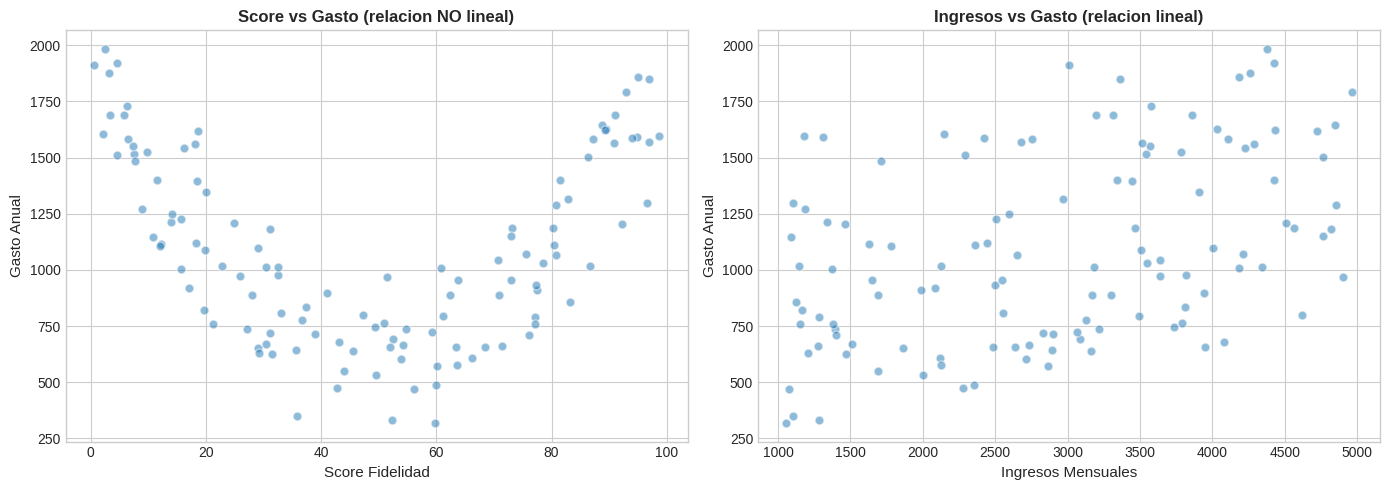

La relacion Score->Gasto es curvilinea (parabolica).
La relacion Ingresos->Gasto es aproximadamente lineal.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(data["Score_Fidelidad"], data["Gasto_Anual"], alpha=0.5, edgecolors="white", s=40)
axes[0].set_xlabel("Score Fidelidad", fontsize=11)
axes[0].set_ylabel("Gasto Anual", fontsize=11)
axes[0].set_title("Score vs Gasto (relacion NO lineal)", fontsize=12, fontweight="bold")

axes[1].scatter(data["Ingresos_Mensuales"], data["Gasto_Anual"], alpha=0.5, edgecolors="white", s=40)
axes[1].set_xlabel("Ingresos Mensuales", fontsize=11)
axes[1].set_ylabel("Gasto Anual", fontsize=11)
axes[1].set_title("Ingresos vs Gasto (relacion lineal)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

print("La relacion Score->Gasto es curvilinea (parabolica).")
print("La relacion Ingresos->Gasto es aproximadamente lineal.")

## 5. Preparacion de datos

**Estandarizacion obligatoria para SVR.** Los kernels SVM son sensibles a la escala de las features.

In [4]:
X = data[["Score_Fidelidad", "Ingresos_Mensuales"]]
y = data["Gasto_Anual"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_s = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

print(f"Train: {X_train_s.shape[0]} | Test: {X_test_s.shape[0]}")
print("Datos estandarizados (media=0, std=1)")

Train: 90 | Test: 30
Datos estandarizados (media=0, std=1)


## 6. Modelo base — Regresion Lineal

In [5]:
lr = LinearRegression()
lr.fit(X_train_s, y_train_s)
y_pred_lr_s = lr.predict(X_test_s)
y_pred_lr = scaler_y.inverse_transform(y_pred_lr_s.reshape(-1, 1)).ravel()

r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
print(f"Regresion Lineal:")
print(f"  R2:  {r2_lr:.4f}")
print(f"  MAE: {mae_lr:.2f} EUR")

Regresion Lineal:
  R2:  -0.0519
  MAE: 313.32 EUR


## 7. SVR con diferentes kernels

In [6]:
kernels = {
    "linear": SVR(kernel="linear", C=1.0),
    "rbf": SVR(kernel="rbf", C=1.0, gamma="scale"),
    "poly": SVR(kernel="poly", C=1.0, degree=2),
}

results = []
predictions = {}

for name, model in kernels.items():
    model.fit(X_train_s, y_train_s)
    y_pred_s = model.predict(X_test_s)
    y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()
    predictions[name] = y_pred

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    results.append({"Kernel": name, "R2": r2, "MAE": mae})
    print(f"SVR ({name}): R2={r2:.4f}, MAE={mae:.2f}")

results_df = pd.DataFrame(results)

SVR (linear): R2=-0.2040, MAE=335.29
SVR (rbf): R2=0.8970, MAE=94.03
SVR (poly): R2=0.7537, MAE=151.45


## 8. Tuning del mejor kernel con GridSearchCV

In [7]:
best_kernel = results_df.loc[results_df["R2"].idxmax(), "Kernel"]
print(f"Mejor kernel: {best_kernel}")

if best_kernel == "rbf":
    param_grid = {
        "C": [0.1, 1, 10, 50, 100],
        "gamma": ["scale", "auto", 0.01, 0.1, 0.5],
        "epsilon": [0.01, 0.05, 0.1, 0.2, 0.5],
    }
elif best_kernel == "poly":
    param_grid = {
        "C": [0.1, 1, 10, 100],
        "degree": [2, 3, 4],
        "epsilon": [0.01, 0.1, 0.2],
    }
else:
    param_grid = {
        "C": [0.1, 1, 10, 100],
        "epsilon": [0.01, 0.1, 0.2],
    }

grid = GridSearchCV(
    SVR(kernel=best_kernel), param_grid, cv=5, scoring="r2", n_jobs=-1
)
grid.fit(X_train_s, y_train_s)

print(f"\nMejores parametros: {grid.best_params_}")
print(f"Mejor R2 (CV): {grid.best_score_:.4f}")

svr_tuned = grid.best_estimator_
y_pred_tuned_s = svr_tuned.predict(X_test_s)
y_pred_tuned = scaler_y.inverse_transform(y_pred_tuned_s.reshape(-1, 1)).ravel()

r2_tuned = r2_score(y_test, y_pred_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
print(f"\nSVR tuneado: R2={r2_tuned:.4f}, MAE={mae_tuned:.2f}")

Mejor kernel: rbf



Mejores parametros: {'C': 50, 'epsilon': 0.1, 'gamma': 0.1}
Mejor R2 (CV): 0.9262

SVR tuneado: R2=0.9335, MAE=76.83


## 9. Comparativa completa

In [8]:
all_results = pd.DataFrame([
    {"Modelo": "Linear Regression", "R2": r2_lr, "MAE": mae_lr},
] + results + [
    {"Modelo": f"SVR {best_kernel} (tuneado)", "R2": r2_tuned, "MAE": mae_tuned},
])
print(all_results.to_string(index=False))

           Modelo        R2        MAE Kernel
Linear Regression -0.051857 313.317360    NaN
              NaN -0.203970 335.293000 linear
              NaN  0.897047  94.034298    rbf
              NaN  0.753700 151.449834   poly
SVR rbf (tuneado)  0.933452  76.832402    NaN


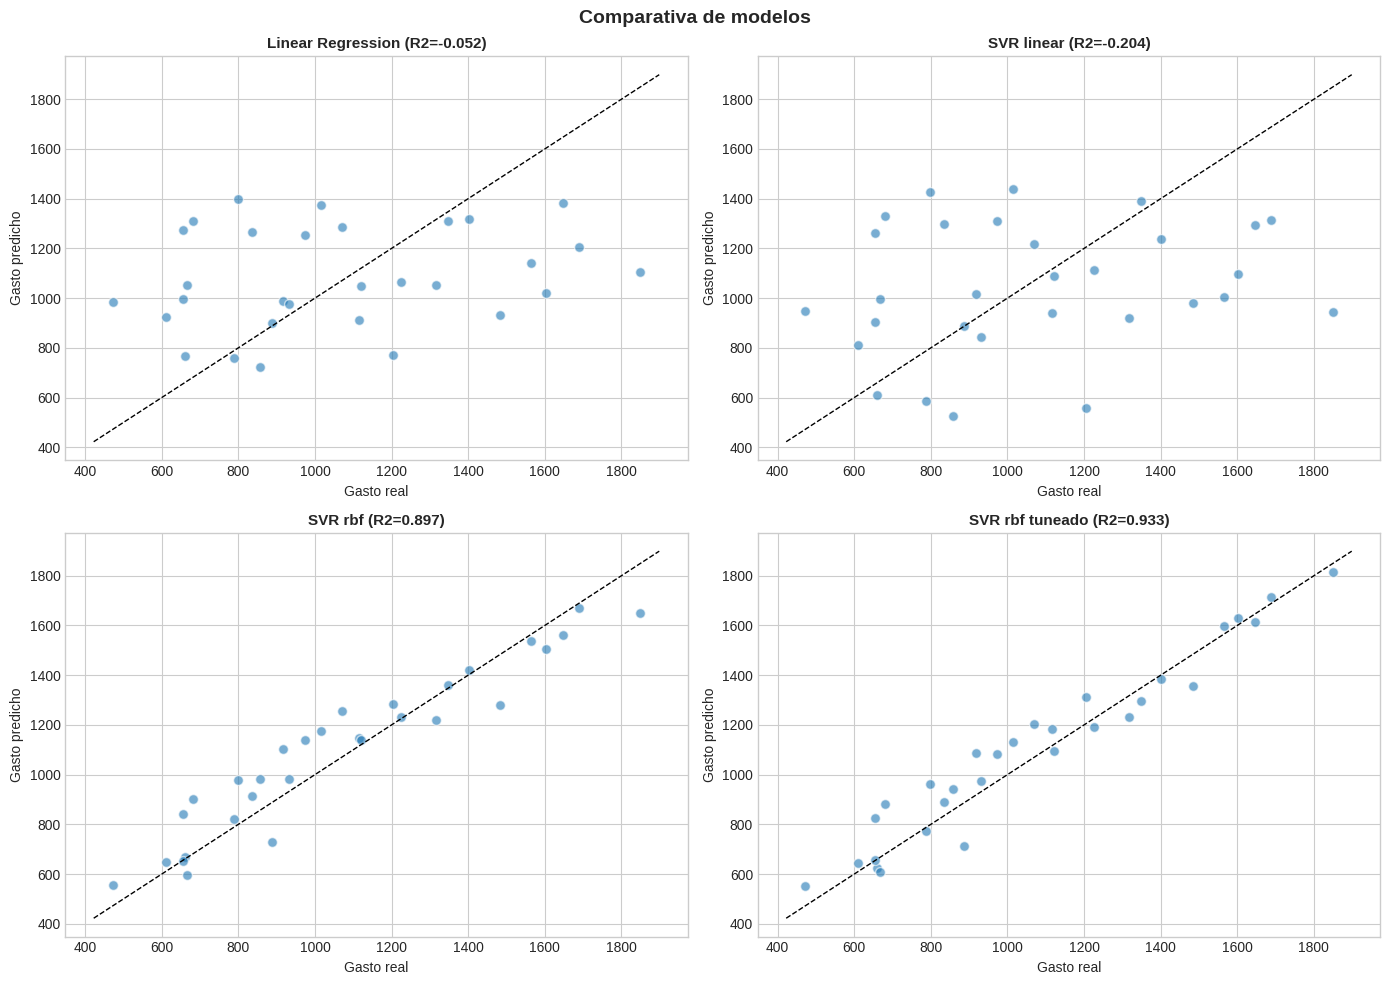

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
models_to_plot = [
    ("Linear Regression", y_pred_lr, r2_lr),
    ("SVR linear", predictions["linear"], results_df[results_df["Kernel"]=="linear"]["R2"].values[0]),
    ("SVR rbf", predictions["rbf"], results_df[results_df["Kernel"]=="rbf"]["R2"].values[0]),
    (f"SVR {best_kernel} tuneado", y_pred_tuned, r2_tuned),
]

for ax, (name, y_p, r2) in zip(axes.ravel(), models_to_plot):
    ax.scatter(y_test, y_p, alpha=0.6, edgecolors="white", s=50)
    lims = [min(y_test.min(), y_p.min())-50, max(y_test.max(), y_p.max())+50]
    ax.plot(lims, lims, "k--", linewidth=1)
    ax.set_xlabel("Gasto real")
    ax.set_ylabel("Gasto predicho")
    ax.set_title(f"{name} (R2={r2:.3f})", fontsize=11, fontweight="bold")

plt.suptitle("Comparativa de modelos", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Insights y recomendaciones

### El hallazgo

> SVR con kernel RBF captura la relacion curvilinea entre fidelidad y gasto que la regresion lineal no puede. El kernel trick transforma el espacio de entrada para encontrar patrones no lineales sin definirlos explicitamente.

### Cuando usar SVR

| Situacion | Recomendacion |
|---|---|
| Relacion lineal, pocas variables | Regresion Lineal |
| Relacion no lineal, dataset pequeno/mediano | **SVR (RBF)** |
| Muchas variables con ruido | Ridge/Lasso |
| Dataset grande, relaciones complejas | Gradient Boosting |

### Recomendacion para el portfolio

SVR complementa el abanico de modelos: regresion lineal para lo simple, regularizacion para lo ruidoso, SVR para lo no lineal con pocos datos, y Gradient Boosting para todo lo demas.

## 11. Limitaciones y proximos pasos

**Limitaciones:**
- Dataset sintetico — los resultados son ilustrativos, no generalizables.
- SVR no da importancia de variables nativa (a diferencia de Gradient Boosting).
- El tuning de C, gamma y epsilon requiere conocimiento del problema.

**Proximos pasos:**
- [ ] [SVR — Baterias](../02-baterias/) — SVR aplicado a prediccion de vida util de baterias.
- [ ] Comparar SVR con [Gradient Boosting](../../04-gradient-boosting/) sobre el mismo dataset.
- [ ] Explorar kernels personalizados para dominios especificos.